In [2]:
import os
import xml
import datetime
import pandas as pd

from osgeo import gdal, osr

gdal.SetConfigOption('GDAL_NUM_THREADS', '4')

import matplotlib.pyplot as plt
import numpy as np

#import xarray as xr

In [60]:
import json
pd.read_json((os.path.join(pdir, '20200101T051701', 'tgt_pln.json')))

,BuoyID,Year,Month,Day,Hour,Minute,Second,Lat,Lon,Delay(Min),BPT,BP,Ts,Ta,Th,Batt,llx,lly,llz,ddt
0,174637,2020,1,1,5.195414,5,0,78.897422,43.808647,0,0.765545,1031.993109,-8.56,-999,-999,11,889199.209956,852969.041418,6.237005e+06,NaN
1618,174637,2020,1,1,0.000000,4,0,78.974100,43.832700,0,0.900000,1031.300000,-8.64,-999,-999,11,882798.514841,847541.033854,6.238643e+06,-18763.490003
1619,174637,2020,1,1,1.000000,4,0,78.960300,43.815900,0,0.400000,1031.300000,-8.64,-999,-999,11,884138.237243,848329.198389,6.238348e+06,-15163.490003
1620,174637,2020,1,1,2.000000,4,0,78.947000,43.805600,0,0.000000,1031.200000,-8.64,-999,-999,11,885342.568448,849179.121953,6.238064e+06,-11563.490003
1621,174637,2020,1,1,3.000000,5,0,78.932800,43.801800,0,0.300000,1031.600000,-8.64,-999,-999,11,886521.923527,850197.423754,6.237759e+06,-7903.490003
1622,174637,2020,1,1,4.000000,5,0,78.917500,43.804000,0,0.700000,1032.000000,-8.64,-999,-999,11,887699.204146,851391.903091,6.237431e+06,-4303.490003
1623,174637,2020,1,1,5.000000,5,0,78.901000,43.808000,0,0.800000,1032.000000,-8.56,-999,-999,11,888944.426648,852705.350713,6.237077e+06,-703.490003
1624,174637,2020,1,1,6.000000,5,0,78.883500,43.810400,0,0.300000,1031.900000,-8.56,-999,-999,11,890292.303644,854069.888844,6.236701e+06,2896.509997
1625,174637,2020,1,1,7.000000,5,0,78.865300,43.808000,0,-0.200000,1031.800000,-8.56,-999,-999,11,891766.985725,855412.844179,6.236308e+06,6496.509997
1626,174637,2020,1,1,8.000000,5,0,78.847400,43.800900,0,5.900000,1037.900000,-8.56,-999,-999,11,893288.248400,856659.567331,6.235922e+06,10096.509997


In [63]:
#(0.195414 *78.8835  + (1 - 0.195414)*78.901)-78.897422
np.uint8

numpy.uint8

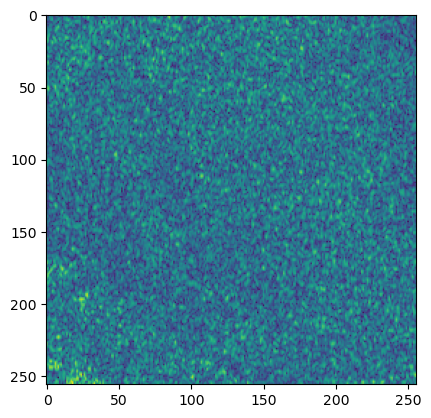

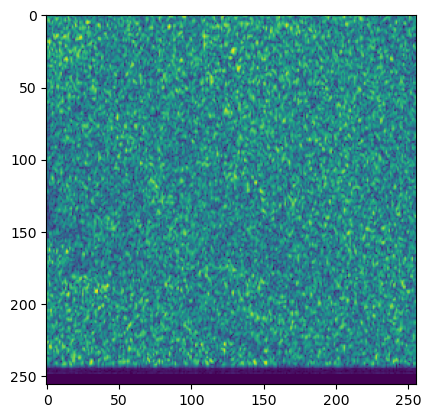

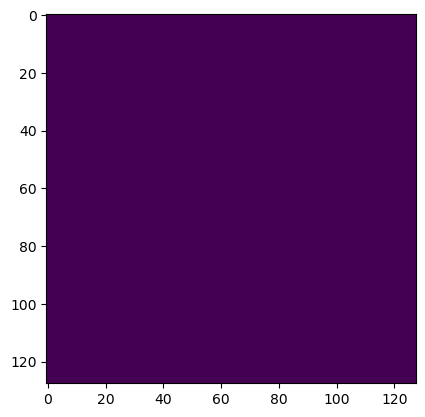

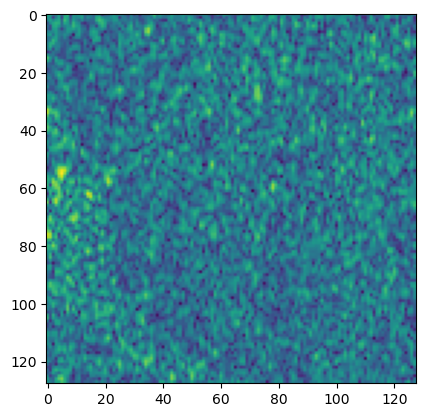

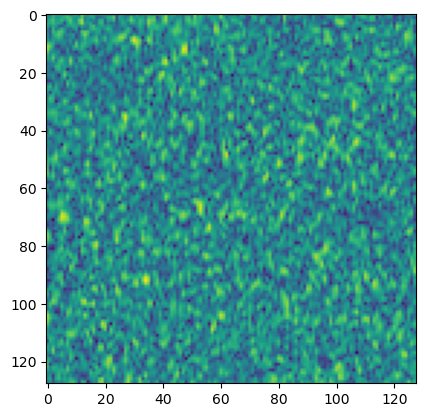

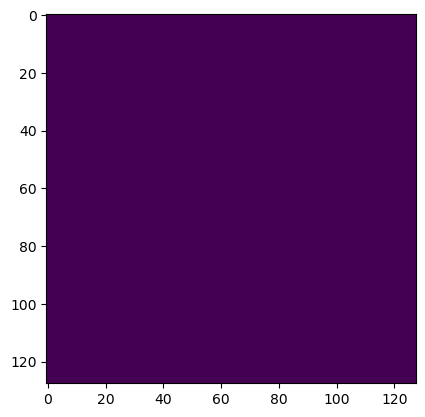

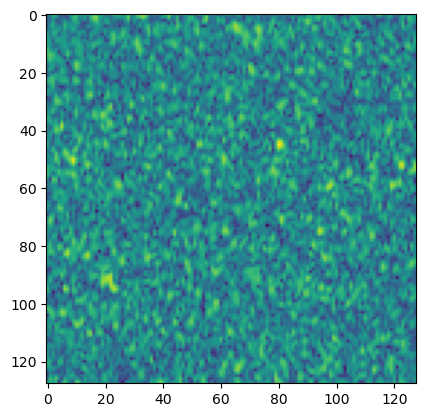

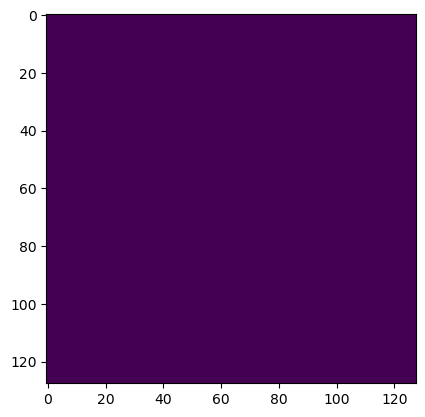

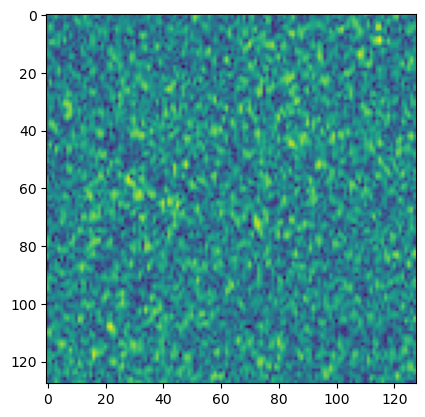

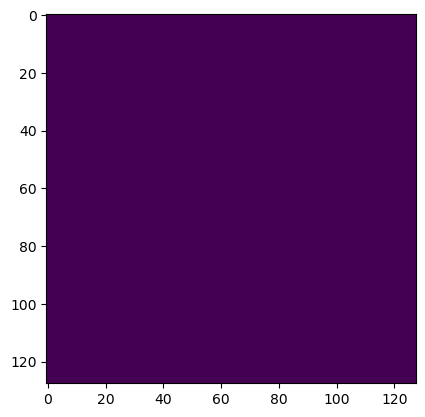

In [58]:
#path = '/mnt/h/data_IceTracker_2020m1/300234066532030/20200126T180844/src.tiff'
pdir = '/mnt/d/data_IceTracker_2020m1/174637'

for i in range(len(os.listdir(pdir))):
    if ('.pickle' in os.listdir(pdir)[i]): continue
    path = os.path.join(pdir, os.listdir(pdir)[i], 'tgt_pln.tiff')
    ds_i = gdal.Open(path)
    ds_i = ds_i.GetRasterBand(1).ReadAsArray()
    plt.imshow((np.abs(ds_i))**0.5); plt.show()

    #path = os.path.join(pdir, os.listdir(pdir)[i], 'src.tiff')
    #ds_i = gdal.Open(path)
    #ds_i = ds_i.GetRasterBand(2).ReadAsArray()[:128,:128]
    #plt.imshow(np.abs(ds_i)); plt.show()

#path2 = '/mnt/h/data_IceTracker_2020m1/300234066532030/20200126T180844/src_grd.tiff'
#path2 = '/mnt/d/data_IceTracker_2020m1/174637/20200101T051701/src_pln.tiff'
#plt.imshow()
#ds_o = gdal.Open(path2)

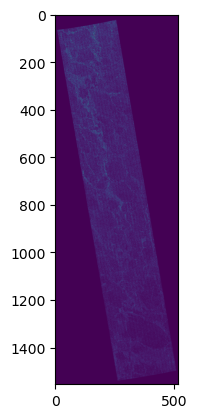

In [16]:
#ds_i.RasterXSize * ds_i.RasterYSize
print('src.tiff:', ds_i.RasterXSize, ds_i.RasterYSize)
print('src_pln.tiff:', ds_o.RasterXSize, ds_o.RasterYSize)

src.tiff: 8329 1169
src_pln.tiff: 38292 27570


In [9]:
srs = osr.SpatialReference(); srs.ImportFromWkt(ds_i.GetGCPProjection())
if srs.GetAuthorityCode(None) != '4326':
    raise ValueError('current program assumes EPSG:4326; input CRS differs.')
srs.GetInvFlattening()

298.257223563

In [44]:
#gt_ds = gdal.Translate('', path1, format='MEM', )
#gdal.Warp(#
wo_ = gdal.SuggestedWarpOutput(ds_i, ["DST_SRS=EPSG:4326"])
resolution = (5e-5, 5e-5)
print(f'GDAL suggested bounds :: iw:{wo_.width} ih:{wo_.height}, xmin:{wo_.xmin}, xmax:{wo_.xmax}, ymin:{wo_.ymin}, ymax:{wo_.ymax}')
print(f'.. fixing from resolution x:{(wo_.xmax - wo_.xmin) / wo_.width}, y:{(wo_.ymax - wo_.ymin) / wo_.height} to x:{resolution[0]}, y:{resolution[1]}')

GDAL suggested bounds :: iw:22804 ih:4504, xmin:-9.719790426331741, xmax:-8.045889526657671, ymin:60.22958724200597, ymax:60.56019808449553
.. fixing from resolution x:7.340382826144843e-05, y:7.340382826144818e-05 to x:5e-05, y:5e-05


In [47]:
import pathlib
ds_i.GetDescription()

'/mnt/h/data_IceTracker_2020m1/300234066532030/20200126T180844/src.tiff'

In [4]:
#ds_o = gdal.GetDriverByName("MEM").Create('', wo_.width, wo_.height, ds_i.RasterCount, ds_i.GetRasterBand(1).DataType)
#gdal.WarpOptions(resampleAlg='N', outputSRS="EPSG:4326", GCPs=gcpList)
#gdal.TranslateOptions()
#gdal.Warp(ds_o, ds_i, 
ds_o = gdal.Translate( "", ds_i, format="MEM", bandList=list(range(1,ds_i.RasterCount+1)),
    xRes=5, yRes=, outputBounds=(wo_.xmin, wo_.ymin, wo_.xmax, wo_.ymax), GCPs=ds_i.GetGCPs())

In [ ]:
gdal.TranslateOptions(

In [ ]:
from osgeo import osr

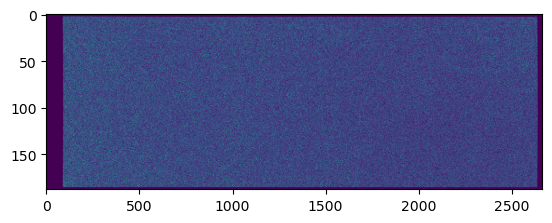

In [22]:
plt.imshow(np.abs(ds_i.GetRasterBand(1).ReadAsArray()[0:-1:8,0:-1:8]), aspect=5)

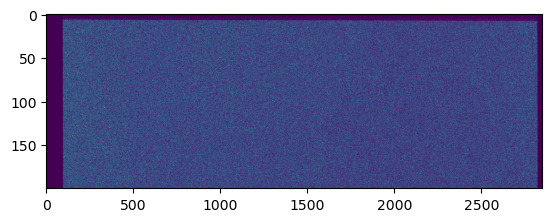

In [18]:
plt.imshow(np.abs(ds_o.GetRasterBand(1).ReadAsArray()[0:-1:8,0:-1:8])[:200], aspect=5)

In [270]:
buoy_data = pd.read_csv('IABP_LEVEL1_2020.csv')

In [295]:
import xml.etree.ElementTree as ET
from osgeo import gdal
import numpy as np

gdal_data = gdal.Open(path + '.tiff')

dal_gcps = pd.DataFrame([{'line':gcp.GCPLine, 'pixel':gcp.GCPPixel,
                           'longitude':gcp.GCPX, 'latitude':gcp.GCPY,
                           'height':gcp.GCPZ} for gcp in gdal_data.GetGCPs()])

burst_idx = int([el for el in path.split('/')[-1].split('_') if len(el)==3 and el[:2]=='IW'][0][-1]) - 1
grid = ET.parse(path + '.xml').getroot().find('metadata').findall('product')[burst_idx].find('content').find('geolocationGrid').find('geolocationGridPointList')
meta_gcps = pd.DataFrame([{e.tag : e.text for e in el} for el in grid])

slc_dt = datetime.datetime.strptime(meta_gcps['azimuthTime'].iloc[0], '%Y-%m-%dT%H:%M:%S.%f')

In [296]:
buoy_id = buoy_data['BuoyID'].iloc[0]
buoy_data = buoy_data[buoy_data['BuoyID']==buoy_id]
buoy_data['dt'] = buoy_data.apply(lambda x: datetime.datetime(int(x['Year']), int(x['Month']), int(x['Day']),
                                                        int(x['Hour']), int(x['Minute']), int(x['Second'])), axis=1)
buoy_data['ddt'] = abs(buoy_data['dt'] - slc_dt)

closest = buoy_data.sort_values(by='ddt').iloc[0]
if (closest.Lon > 180): closest.Lon -= 360